In [1]:
print("hello")

hello


In [2]:
import pandas as pd

df = pd.read_excel("../data/online_retail.xlsx")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/online_retail.xlsx'

In [3]:
import os
os.listdir("../data")

[]

In [4]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.shape

(541909, 8)

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.describe(include="object")

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [9]:
retail = df.copy()
retail.shape

(541909, 8)

In [10]:
retail = retail.dropna(subset=["Description"])
retail.shape

(540455, 8)

In [11]:
retail.duplicated().sum()

np.int64(5268)

In [12]:
retail = retail.drop_duplicates()
retail.shape

(535187, 8)

In [13]:
retail["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [14]:
retail = retail[~retail["InvoiceNo"].astype(str).str.startswith("C")]
retail.shape

(525936, 8)

In [15]:
retail = retail[retail["Quantity"] > 0]
retail = retail[retail["UnitPrice"] > 0]
retail.shape

(524878, 8)

In [16]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

In [17]:
retail["Sales"] = retail["Quantity"] * retail["UnitPrice"]
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
retail["YearMonth"] = retail["InvoiceDate"].dt.to_period("M").astype(str)
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [19]:
retail["InvoiceDay"] = retail["InvoiceDate"].dt.date
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,YearMonth,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01


In [20]:
total_sales = retail["Sales"].sum()
total_orders = retail["InvoiceNo"].nunique()
total_products = retail["StockCode"].nunique()
total_customers = retail["CustomerID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Customers:", total_customers)

Total Sales: 10642110.8
Total Orders: 19960
Total Products: 3922
Total Customers: 4338


In [21]:
country_sales = (
    retail.groupby("Country", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

country_sales.head(10)

,Country,Sales
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Top 10 Countries by Sales'}, xlabel='Country'>

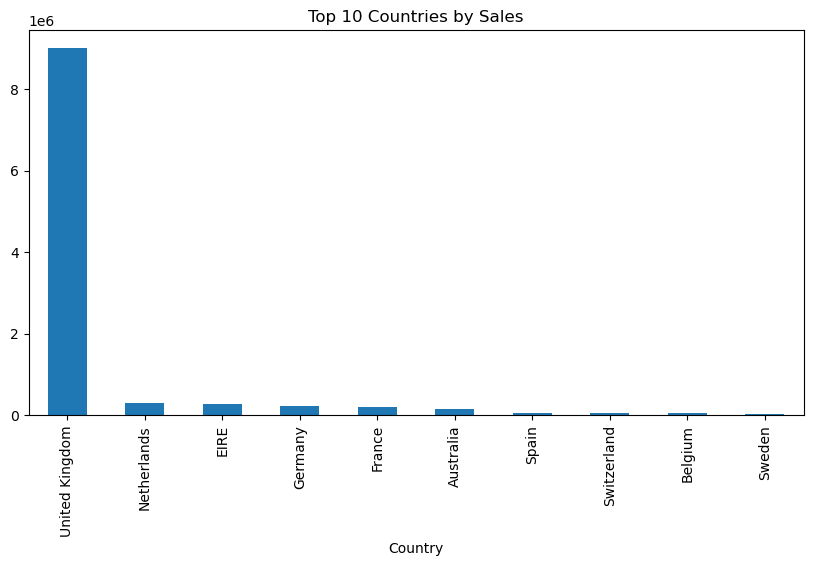

In [22]:
top10_country_sales = country_sales.head(10)

top10_country_sales.plot(
    x="Country",
    y="Sales",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Top 10 Countries by Sales"
)

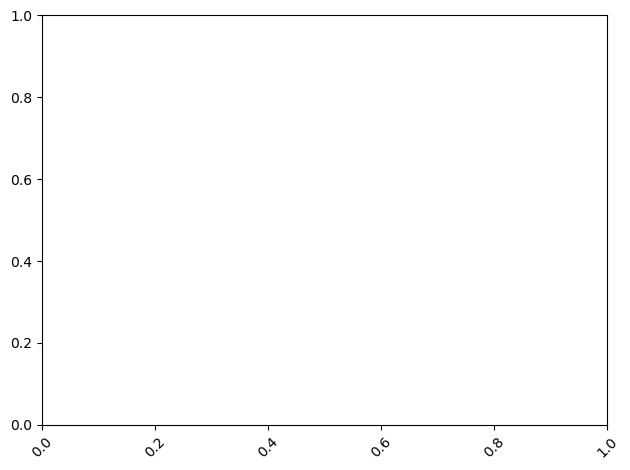

In [23]:
import matplotlib.pyplot as plt
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
product_sales = (
    retail.groupby("Description", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

product_sales.head(10)

,Description,Sales
1067,DOTCOM POSTAGE,206248.77
2853,REGENCY CAKESTAND 3 TIER,174156.54
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
2413,PARTY BUNTING,99445.23
1816,JUMBO BAG RED RETROSPOT,94159.81
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2692,POSTAGE,78101.88
2192,Manual,77752.82
2741,RABBIT NIGHT LIGHT,66870.03


In [25]:
product_quantity = (
    retail.groupby("Description", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
)

product_quantity.head(10)

,Description,Quantity
2387,"PAPER CRAFT , LITTLE BIRDIE",80995
2052,MEDIUM CERAMIC TOP STORAGE JAR,78033
3934,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
1816,JUMBO BAG RED RETROSPOT,48371
3844,WHITE HANGING HEART T-LIGHT HOLDER,37872
2681,POPCORN HOLDER,36749
2337,PACK OF 72 RETROSPOT CAKE CASES,36396
227,ASSORTED COLOUR BIRD ORNAMENT,36362
2741,RABBIT NIGHT LIGHT,30739
2107,MINI PAINT SET VINTAGE,26633


In [26]:
monthly_sales = (
    retail.groupby("YearMonth", as_index=False)["Sales"]
    .sum()
    .sort_values("YearMonth")
)

monthly_sales

,YearMonth,Sales
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


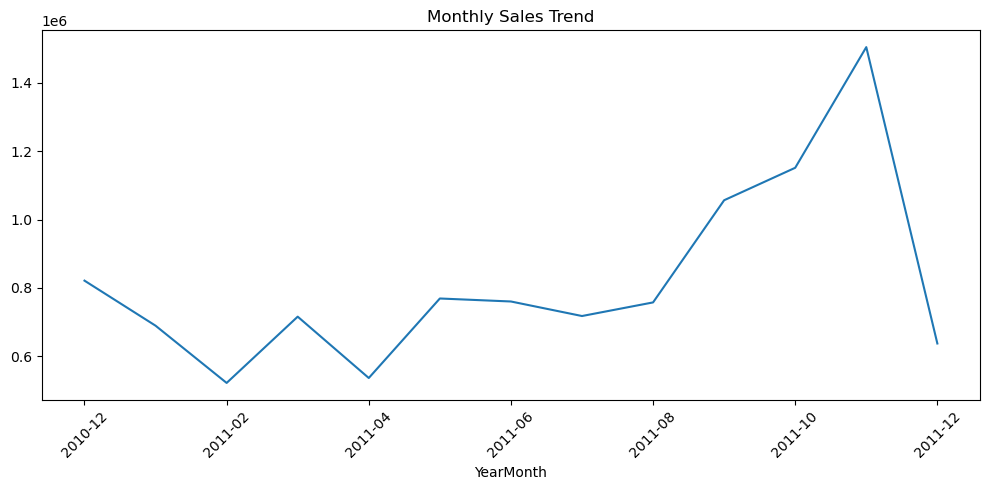

In [27]:
monthly_sales.plot(
    x="YearMonth",
    y="Sales",
    kind="line",
    figsize=(10, 5),
    legend=False,
    title="Monthly Sales Trend"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
daily_orders = (
    retail.groupby("InvoiceDay", as_index=False)["InvoiceNo"]
    .nunique()
    .rename(columns={"InvoiceNo": "OrderCount"})
)

daily_orders.head()

,InvoiceDay,OrderCount
0,2010-12-01,127
1,2010-12-02,142
2,2010-12-03,68
3,2010-12-05,88
4,2010-12-06,102


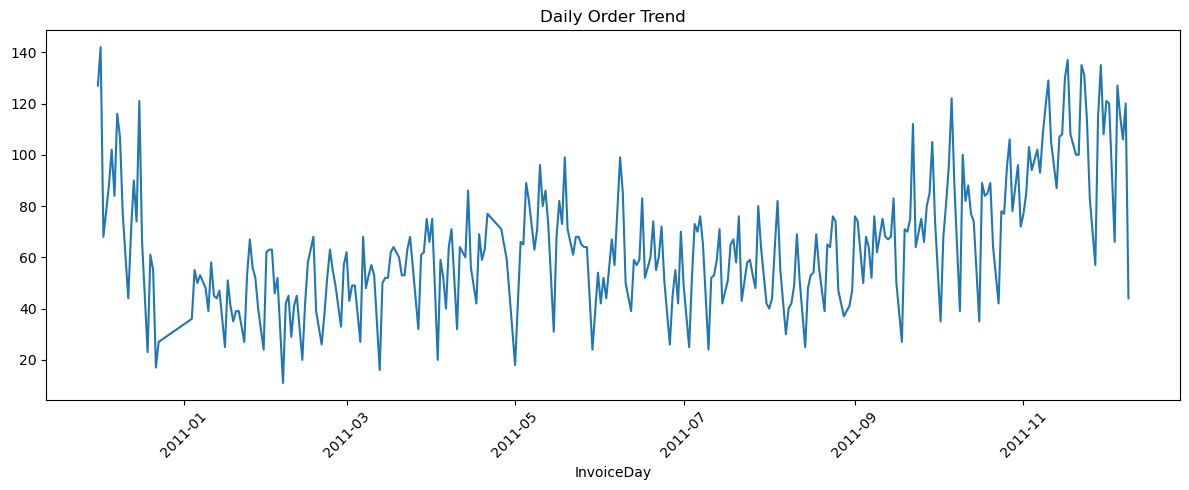

In [29]:
daily_orders.plot(
    x="InvoiceDay",
    y="OrderCount",
    kind="line",
    figsize=(12, 5),
    legend=False,
    title="Daily Order Trend"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
customer_df = retail.dropna(subset=["CustomerID"]).copy()
customer_df.shape

(392692, 11)

In [31]:
snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Sales": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [32]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [33]:
rfm.sort_values(["Monetary", "Frequency"], ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary
1689,14646.0,2,73,280206.02
4201,18102.0,1,60,259657.30
3728,17450.0,8,46,194390.79
3008,16446.0,1,2,168472.50
1879,14911.0,1,201,143711.17
55,12415.0,24,21,124914.53
1333,14156.0,10,55,117210.08
3771,17511.0,3,31,91062.38
2702,16029.0,39,63,80850.84
0,12346.0,326,1,77183.60


In [34]:
rfm["CustomerType"] = "Regular"

rfm.loc[
    (rfm["Monetary"] >= rfm["Monetary"].quantile(0.75)) &
    (rfm["Frequency"] >= rfm["Frequency"].quantile(0.75)),
    "CustomerType"
] = "High Value"

rfm.loc[
    (rfm["Recency"] >= rfm["Recency"].quantile(0.75)),
    "CustomerType"
] = "At Risk"

rfm["CustomerType"].value_counts()

CustomerType
Regular       2428
At Risk       1088
High Value     822
Name: count, dtype: int64

In [35]:
rfm.groupby("CustomerType")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
CustomerType,,,
At Risk,246.594669,1.626838,649.899293
High Value,22.367397,12.688564,7254.713869
Regular,47.257825,2.607908,912.991624


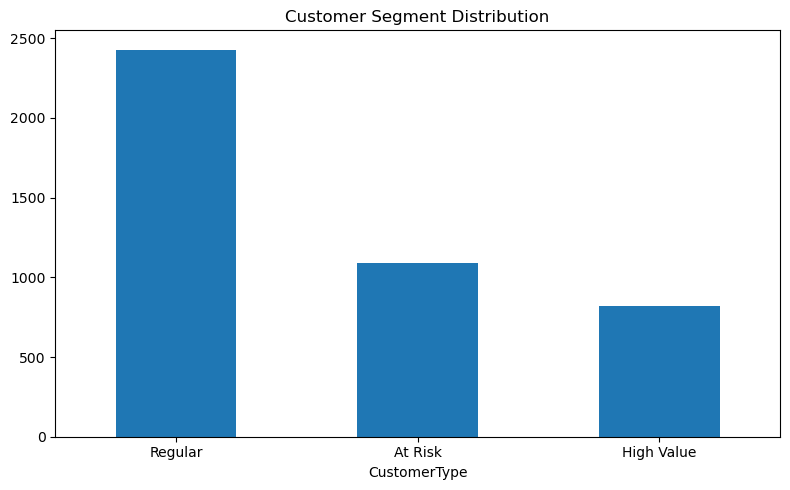

In [36]:
rfm["CustomerType"].value_counts().plot(
    kind="bar",
    figsize=(8, 5),
    title="Customer Segment Distribution"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
country_sales.to_excel("../outputs/country_sales.xlsx", index=False)
product_sales.to_excel("../outputs/product_sales.xlsx", index=False)
monthly_sales.to_excel("../outputs/monthly_sales.xlsx", index=False)
rfm.to_excel("../outputs/customer_rfm.xlsx", index=False)

In [38]:
retail = df.copy()

retail = retail.dropna(subset=["Description"])
retail = retail.drop_duplicates()
retail = retail[~retail["InvoiceNo"].astype(str).str.startswith("C")]
retail = retail[retail["Quantity"] > 0]
retail = retail[retail["UnitPrice"] > 0]

retail["Sales"] = retail["Quantity"] * retail["UnitPrice"]
retail["YearMonth"] = retail["InvoiceDate"].dt.to_period("M").astype(str)
retail["InvoiceDay"] = retail["InvoiceDate"].dt.date

retail.shape

(524878, 11)

In [39]:
total_sales = retail["Sales"].sum()
total_orders = retail["InvoiceNo"].nunique()
total_products = retail["StockCode"].nunique()
total_customers = retail["CustomerID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Customers:", total_customers)

Total Sales: 10642110.8
Total Orders: 19960
Total Products: 3922
Total Customers: 4338


In [40]:
country_sales = (
    retail.groupby("Country", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

country_sales.head(10)

,Country,Sales
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


In [41]:
product_sales = (
    retail.groupby("Description", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

product_sales.head(10)

,Description,Sales
1067,DOTCOM POSTAGE,206248.77
2853,REGENCY CAKESTAND 3 TIER,174156.54
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
2413,PARTY BUNTING,99445.23
1816,JUMBO BAG RED RETROSPOT,94159.81
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2692,POSTAGE,78101.88
2192,Manual,77752.82
2741,RABBIT NIGHT LIGHT,66870.03


In [42]:
monthly_sales = (
    retail.groupby("YearMonth", as_index=False)["Sales"]
    .sum()
    .sort_values("YearMonth")
)

monthly_sales

,YearMonth,Sales
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


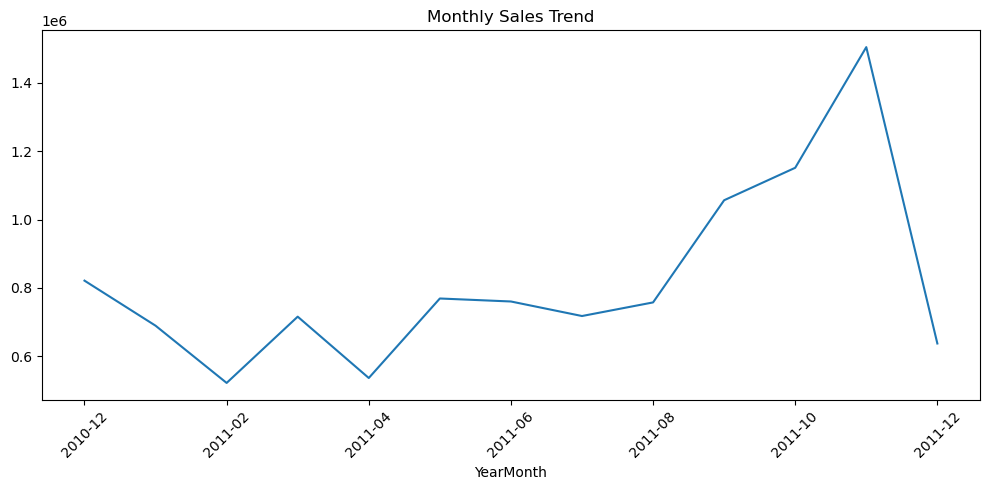

In [43]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    x="YearMonth",
    y="Sales",
    kind="line",
    figsize=(10, 5),
    legend=False,
    title="Monthly Sales Trend"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
customer_summary = (
    retail.groupby("CustomerID")
    .agg({
        "Sales": "sum",
        "InvoiceNo": "nunique"
    })
    .rename(columns={
        "Sales": "TotalSpend",
        "InvoiceNo": "TotalOrders"
    })
)

customer_summary.head()

,TotalSpend,TotalOrders
CustomerID,,
12346.0,77183.60,1
12347.0,4310.00,7
12348.0,1797.24,4
12349.0,1757.55,1
12350.0,334.40,1


In [45]:
customer_summary.describe()

,TotalSpend,TotalOrders
count,4338.000000,4338.000000
mean,2048.688081,4.272015
std,8985.230220,7.697998
min,3.750000,1.000000
25%,306.482500,1.000000
50%,668.570000,2.000000
75%,1660.597500,5.000000
max,280206.020000,209.000000


In [46]:
top_customers = customer_summary.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

top_customers

,TotalSpend,TotalOrders
CustomerID,,
14646.0,280206.02,73
18102.0,259657.30,60
17450.0,194390.79,46
16446.0,168472.50,2
14911.0,143711.17,201
12415.0,124914.53,21
14156.0,117210.08,55
17511.0,91062.38,31
16029.0,80850.84,63


In [47]:
customer_summary["Segment"] = pd.qcut(
    customer_summary["TotalSpend"],
    q=4,
    labels=["Low", "Medium", "High", "VIP"]
)

customer_summary.head()

,TotalSpend,TotalOrders,Segment
CustomerID,,,
12346.0,77183.60,1,VIP
12347.0,4310.00,7,VIP
12348.0,1797.24,4,VIP
12349.0,1757.55,1,VIP
12350.0,334.40,1,Medium


In [48]:
import datetime as dt

snapshot_date = retail["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = retail.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [49]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"], 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

ValueError: Bin edges must be unique: Index([1.0, 1.0, 2.0, 5.0, 209.0], dtype='float64', name='Frequency').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [50]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1], duplicates="drop")
rfm["F_score"] = pd.qcut(rfm["Frequency"], 4, labels=[1,2,3,4], duplicates="drop")
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4], duplicates="drop")

ValueError: Bin labels must be one fewer than the number of bin edges

In [51]:
rfm["R_score"] = pd.qcut(rfm["Recency"], q=4, duplicates="drop")
rfm["F_score"] = pd.qcut(rfm["Frequency"], q=4, duplicates="drop")
rfm["M_score"] = pd.qcut(rfm["Monetary"], q=4, duplicates="drop")

In [52]:
rfm["R_score"] = rfm["R_score"].cat.codes + 1
rfm["F_score"] = rfm["F_score"].cat.codes + 1
rfm["M_score"] = rfm["M_score"].cat.codes + 1

In [53]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,326,1,77183.60,4,1,4
12347.0,2,7,4310.00,1,3,4
12348.0,75,4,1797.24,3,2,4
12349.0,19,1,1757.55,2,1,4
12350.0,310,1,334.40,4,1,2


In [54]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,4,1,4,414
12347.0,2,7,4310.00,1,3,4,134
12348.0,75,4,1797.24,3,2,4,324
12349.0,19,1,1757.55,2,1,4,214
12350.0,310,1,334.40,4,1,2,412


In [55]:
def segment_customer(row):
    if row["RFM_score"] == "444":
        return "VIP"
    elif row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Loyal"
    elif row["R_score"] <= 2:
        return "At Risk"
    else:
        return "Regular"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm["Segment"].value_counts()

Segment
Regular    2040
At Risk    1434
Loyal       864
Name: count, dtype: int64

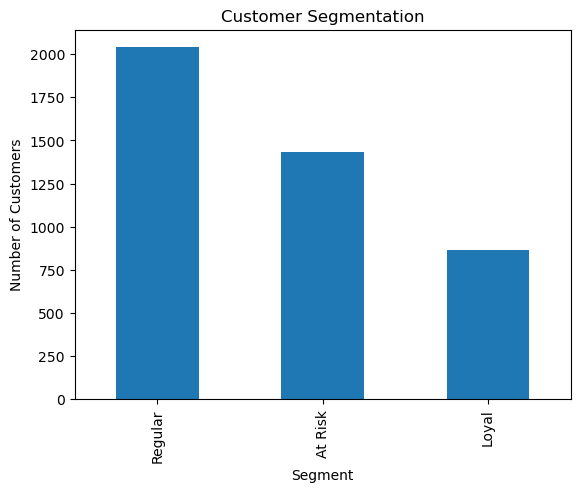

In [56]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [57]:
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,22.950488,2.652720,1066.145928
Loyal,25.002315,12.770833,6818.078021
Regular,170.053922,1.810784,719.380501
